# ADSP 32018 IP01 Next-Gen NLP: Transformers, LLMs and AgenticAI in Practice - Final Project

## Part 2: Data Preprocessing

**Objective of this notebook:**
- Build a reproducible cleaning and filtering pipeline for the news dataset.
- Remove crawl noise and likely irrelevant rows before topic/entity/sentiment work.
- Save a model-ready dataset and transparent filtering artifacts.

**Plan:**
- Standardize raw columns and parse dates/URLs/text fields.
- Apply rule-based quality filters for noise and low-information content.
- Score article relevance to AI/ML topics and keep high-signal rows.
- Deduplicate and export cleaned data with diagnostics.

## 0. Imports and Notebook Setup

### 0.1 Load packages for data processing and diagnostics

This section imports the core libraries used throughout the cleaning and filtering pipeline. The notebook mainly relies on pandas and NumPy for table operations, regular expressions for rule-based text processing, and matplotlib for final diagnostic plots.

In [ ]:
from pathlib import Path
import re

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

### 0.2 Load the raw dataset and confirm the input schema

This step loads the source parquet file from local storage if it already exists, or downloads it otherwise. Printing the row count and column names at the beginning helps confirm that the notebook is working with the expected raw input before any preprocessing or filtering is applied.

In [3]:
DATA_DIR = Path("data/")
DATA_DIR.mkdir(parents=True, exist_ok=True)

if not (DATA_DIR / "raw/news_final_project.parquet").exists():
    print("Downloading data...")
    df = pd.read_parquet("https://storage.googleapis.com/msca-bdp-data-open/news_final_project/news_final_project.parquet", engine="pyarrow")
    print("Data downloaded successfully.")
    df.to_parquet(DATA_DIR / "raw/news_final_project.parquet", engine="pyarrow")
else:
    df = pd.read_parquet(DATA_DIR / "raw/news_final_project.parquet", engine="pyarrow")
    print("Data loaded.")

print(f"Rows: {df.shape[0]:,} | Columns: {df.shape[1]:,}")
print(f"Columns: {', '.join(df.columns)}")

Data loaded.
Rows: 199,989 | Columns: 5
Columns: url, date, language, title, text


### 0.3 Create a working copy and standardize key identifiers

Here I create a working dataframe, assign a stable `row_id`, and parse the date column into a consistent datetime format. This gives the rest of the notebook a clean base table that can be safely transformed without modifying the original raw dataframe.

In [4]:
work_df = df.copy()
work_df["row_id"] = np.arange(len(work_df))
work_df["date"] = pd.to_datetime(work_df["date"], errors="coerce", utc=True).dt.tz_localize(None)

parse_success_pct = work_df["date"].notna().mean() * 100
print(f"Date parse success: {parse_success_pct:.2f}%")
display(work_df.head(3))

Date parse success: 100.00%


,url,date,language,title,text,row_id
0,https://blockworks.co/price/bad,2025-06-23,en,"Bad Idea AI Price (BAD), Market Cap, Price Today & Chart History - Blockworks","Bad Idea AI Price (BAD), Market Cap, Price Today & Chart History - BlockworksOpen menuBrandsnewsletterspodcastseventsroundtablestoken transparencyetf trackerpricesresearchanalyticshomepricesBad Idea AI price (BAD)Bad...",0
1,https://boingboing.net/2024/07/01/this-ai-video-of-gymnastics-might-be-the-freakiest-ive-seen-yet.html,2024-07-01,en,This AI video of gymnastics might be the freakiest I've seen yet - Boing Boing,\n\nThis AI video of gymnastics might be the freakiest I've seen yet - Boing Boing\n\n \n\t\t\t\t\tMENU \n\n\t\t\t\t\t\tSEARCH \n\n\t\t\t\t\t\tSTORE \n\n\n\t\t\t\t...,1
2,https://boingboing.net/2024/09/18/if-using-ai-feels-like-a-chore-try-this.html,2024-09-22,en,"If using AI feels like a chore, try this - Boing Boing","\n\nIf using AI feels like a chore, try this - Boing Boing\n \n\t\t\t\t\tMENU \n\n\t\t\t\t\t\tSEARCH \n\n\t\t\t\t\t\tSTORE \n\n\n\t\t\t\t\t\t\tMENU ...",2


**Section takeaway:** At this point, the raw dataset has been loaded successfully and converted into a working table with stable row identifiers and standardized dates, which makes the later filtering steps reproducible.

## 1. AI-Focused Evidence Extraction

### 1.1 Define AI trigger patterns and extract evidence-rich paragraphs

The raw crawled article text may contain a large amount of unrelated page content. This section defines a set of AI-related trigger terms and keeps only the paragraphs that contain direct AI evidence or are close to such evidence, so the downstream cleaning steps focus on the most relevant article content rather than full-page crawl noise.

In [5]:
AI_TRIGGER_PATTERNS = [
    r"\bai\b",
    r"artificial intelligence",
    r"\bml\b",
    r"machine learning",
    r"deep learning",
    r"\bllm\b",
    r"large language model",
    r"generative ai",
    r"\bgenai\b",
    r"chatgpt",
    r"gpt[- ]?\d+",
    r"openai",
    r"transformer(s)?",
    r"diffusion",
    r"stable diffusion"
]
AI_TRIGGER_RE = re.compile("|".join(f"(?:{p})" for p in AI_TRIGGER_PATTERNS), flags=re.I)

def split_paragraphs(text: str) -> list[str]:
    """
    Split by line breaks and remove empty-ish paragraphs.
    Keeps order.
    """
    if text is None or (isinstance(text, float) and np.isnan(text)):
        return []
    s = str(text).replace("\r\n", "\n").replace("\r", "\n")
    parts = [p.strip() for p in s.split("\n")]
    return [p for p in parts if len(p) > 0]


def token_len(s: str) -> int:
    return len(re.findall(r"\S+", s or ""))


def extract_ai_paragraphs(
    text: str,
    min_tokens_keep: int = 20,
) -> tuple[str, dict]:
    
    paras = split_paragraphs(text)
    if not paras:
        return "", {
            "n_paras": 0,
            "kept_paras": 0,
            "kept_core": 0
        }

    keep_core_idx = []

    for i, p in enumerate(paras):
        if AI_TRIGGER_RE.search(p):
            if token_len(p) >= min_tokens_keep:
                keep_core_idx.append(i)

    keep_idx = set(keep_core_idx)

    keep_idx_sorted = sorted(keep_idx)
    kept_paras = [paras[i] for i in keep_idx_sorted]

    extracted = "\n".join(kept_paras).strip()

    return extracted, {
        "n_paras": len(paras),
        "kept_paras": len(keep_idx_sorted),
        "kept_core": len(keep_core_idx),
    }


TEXT_COL = "text"

min_tokens_keep = 20

results = work_df[TEXT_COL].apply(
    lambda t: extract_ai_paragraphs(
        t, min_tokens_keep=min_tokens_keep,
    )
)

work_df["ai_evidence_text"] = results.apply(lambda x: x[0])
diag_df = pd.json_normalize(results.apply(lambda x: x[1]))

work_df = pd.concat([work_df, diag_df.add_prefix("ai_extract_")], axis=1)

work_df["has_ai_evidence"] = work_df["ai_evidence_text"].str.len().fillna(0).gt(0)

print("Rows:", len(work_df))
print("Rows with evidence:", work_df["has_ai_evidence"].sum())
print("Share with evidence:", round(work_df["has_ai_evidence"].mean() * 100, 2), "%")

display(
    work_df.loc[work_df["has_ai_evidence"], ["ai_evidence_text"]]
    .head(5)
)

Rows: 199989
Rows with evidence: 191085
Share with evidence: 95.55 %


,ai_evidence_text
0,"Bad Idea AI Price (BAD), Market Cap, Price Today & Chart History - BlockworksOpen menuBrandsnewsletterspodcastseventsroundtablestoken transparencyetf trackerpricesresearchanalyticshomepricesBad Idea AI price (BAD)Bad..."
1,"I'm sure by now you're tired of looking at terrible or terribly weird AI art, but bear with me. This AI video of gymnasts in action is truly one of the strangest creations of AI art I've seen to date. I'm ashamed to ..."
2,"AI isn't going anywhere. The problem is that we're going everywhere trying to use it. If you want to make a blog post, you might stop by ChatGPT for the copy, head on over to midjourney for an image, and pop on by tw..."
3,O camiño por diante: como o modelo da Fundación AI de China está a dar forma ao futuro da tecnoloxía de condución autónoma\nO camiño por diante: como o modelo da Fundación AI de China está a dar forma ao futuro da te...
4,"Microsoft and Nvidia are joining forces to provide developers with the tools they need to run and customize AI models on Windows PCs. At the Microsoft Ignite event, Microsoft unveiled Windows AI Studio, a centralized..."


### 1.2 Replace the original article body with the extracted evidence text

After the evidence extraction step, I keep only the core columns needed for downstream analysis and overwrite the article text with the AI-focused evidence text. This reduces noise early and ensures that later token counts, quality checks, and relevance scoring are computed from the most informative text span.

In [8]:
work_df = work_df[["row_id", "url", "date", "language", "title", "text", "ai_evidence_text"]].copy()
work_df["text"] = work_df["ai_evidence_text"]
work_df.drop(columns=["ai_evidence_text"], inplace=True)

**Section takeaway:** The notebook now works with a narrower, AI-centered version of each article, which improves the signal-to-noise ratio before text cleaning and filtering.

## 2. Light Text Cleaning and Basic Diagnostics

### 2.1 Apply lightweight text normalization to titles and article text

This section performs a light cleaning pass that removes HTML tags, URLs, repeated separators, and excessive whitespace while preserving the article wording as much as possible. The goal is not aggressive normalization, but rather a model-friendly version of the text that is easier to inspect, score, and compare across rows.

In [9]:
def clean_text_light(series: pd.Series) -> pd.Series:
    s = series.fillna("").astype("string")
    s = s.str.replace(r"<[^>]+>", " ", regex=True)
    s = s.str.replace(r"http[s]?://\S+|www\.\S+", " ", regex=True)
    s = s.str.replace(r"-{2,}", " ", regex=True)
    s = s.str.replace(r"[_=]{2,}", " ", regex=True)
    s = s.str.replace(r"(\s)+", " ", regex=True)
    s = s.astype("object").str.replace(r"([^a-zA-Z0-9])\1+", r"\1", regex=True)

    return s.astype("string").str.strip()


work_df["title_clean"] = clean_text_light(work_df["title"])

work_df["text_clean_light"] = clean_text_light(work_df["text"])
work_df["combined_text"] = (work_df["title_clean"] + " " + work_df["text_clean_light"]).str.strip()

work_df["char_count"] = work_df["text_clean_light"].str.len()
work_df["token_count"] = work_df["text_clean_light"].str.split().str.len()
char_nonzero = work_df["char_count"].replace(0, np.nan)
work_df["alpha_ratio"] = (work_df["text_clean_light"].str.count(r"[A-Za-z]") / char_nonzero).fillna(0.0)

display(work_df[["title", "title_clean", "text", "text_clean_light"]].head(3))

,title,title_clean,text,text_clean_light
0,"Bad Idea AI Price (BAD), Market Cap, Price Today & Chart History - Blockworks","Bad Idea AI Price (BAD), Market Cap, Price Today & Chart History - Blockworks","Bad Idea AI Price (BAD), Market Cap, Price Today & Chart History - BlockworksOpen menuBrandsnewsletterspodcastseventsroundtablestoken transparencyetf trackerpricesresearchanalyticshomepricesBad Idea AI price (BAD)Bad...","Bad Idea AI Price (BAD), Market Cap, Price Today & Chart History - BlockworksOpen menuBrandsnewsletterspodcastseventsroundtablestoken transparencyetf trackerpricesresearchanalyticshomepricesBad Idea AI price (BAD)Bad..."
1,This AI video of gymnastics might be the freakiest I've seen yet - Boing Boing,This AI video of gymnastics might be the freakiest I've seen yet - Boing Boing,"I'm sure by now you're tired of looking at terrible or terribly weird AI art, but bear with me. This AI video of gymnasts in action is truly one of the strangest creations of AI art I've seen to date. I'm ashamed to ...","I'm sure by now you're tired of looking at terrible or terribly weird AI art, but bear with me. This AI video of gymnasts in action is truly one of the strangest creations of AI art I've seen to date. I'm ashamed to ..."
2,"If using AI feels like a chore, try this - Boing Boing","If using AI feels like a chore, try this - Boing Boing","AI isn't going anywhere. The problem is that we're going everywhere trying to use it. If you want to make a blog post, you might stop by ChatGPT for the copy, head on over to midjourney for an image, and pop on by tw...","AI isn't going anywhere. The problem is that we're going everywhere trying to use it. If you want to make a blog post, you might stop by ChatGPT for the copy, head on over to midjourney for an image, and pop on by tw..."


### 2.2 Inspect a small random sample of original versus cleaned text

A quick manual spot check is useful after any cleaning step because it helps verify that the normalization is removing web noise without damaging the semantic content of the article. Looking at a few random examples also makes it easier to catch formatting issues before the filtering logic is applied to the full dataset.

In [ ]:
sample_rows = work_df.sample(5, random_state=42)
for idx, row in sample_rows.iterrows():
    print(f"Row ID: {row['row_id']}")
    print(f"Original Title: {row['title']}")
    print(f"Cleaned Title: {row['title_clean']}")
    print(f"Original Text: {row['text']}")
    print(f"Cleaned Text: {row['text_clean_light']}")
    print("-" * 80)

Row ID: 129081
Original Title: Researchers have developed an AI tool that can closely imitate your handwriting style – Cedar News English
Cleaned Title: Researchers have developed an AI tool that can closely imitate your handwriting style – Cedar News English
Original Text: The Mohamad Bin Zayed University of Artificial Intelligence claims to be the first AI university in the world.   iStock   A team of inventors have received a patent from the US for an AI tool that can copy people’s handwriting.It’s able to produce text based off just a few paragraphs of a person’s original handwriting. However, the team said they’re being cautious because it can be misused for forgery.   AI can clone your voice, and create deepfake images, and it’s soon going to come for your handwriting style too.    A team of researchers at the Mohamed Bin Zayed University of Artificial Intelligence in Abu Dhabi have developed an AI system that can learn people’s handwriting style and generate text that looks extr

**Section takeaway:** The text has now been lightly normalized and checked manually, so the dataset is ready for rule-based quality filtering without relying on visibly noisy raw crawl text.

## 3. Rule-Based Quality Filtering

### 3.1 Flag low-quality or noisy rows using transparent filtering rules

This section creates interpretable quality flags for common crawl problems such as empty text, very short low-information content, boilerplate page fragments, HTML artifacts, and non-English rows. Instead of dropping rows immediately, I first record the impact of each rule so that the filtering decisions remain auditable and easy to explain.

In [12]:
DROP_NON_ENGLISH = True

boilerplate_pattern = (
    r"cookie policy|cookies settings|cookie settings|accept cookies|reject cookies|manage cookies|"
    r"privacy policy|privacy notice|do not sell|do not share|terms of service|terms of use|"
    r"all rights reserved|copyright\s*\d{4}|©\s*\d{4}|"
    r"sign in|log in|login|log out|logout|register|create account|subscribe|subscription|"
    r"newsletter|sign up|get the newsletter|email address|"
    r"advertisement|sponsored|sponsor(ed)? content|promoted|"
    r"share this|share on|facebook|twitter|x\.com|linkedin|reddit|whatsapp|telegram|"
    r"comment(s)?|leave a comment|add comment|view comments|"
    r"skip to main content|back to top|site map|sitemap|"
    r"download (the )?app|open in app|app store|google play|"
    r"enable javascript|turn on javascript|adblock|disable adblock|"
    r"consent|gdpr|ccpa|cmp|one ?trust|trustarc|quantcast|"
    r"related articles|recommended for you|more (stories|news)|trending|most read|"
    r"read more|continue reading|show more|load more|"
    r"contact us|about us|careers|help|support|faq|"
    r"breaking news|latest headlines|"
    r"by continuing to use|we value your privacy|"
    r"accessibility statement|accessibility|"
    r"powered by|affiliate link"
)

flags_df = pd.DataFrame(
    {
        "is_empty_text": work_df["text_clean_light"].str.strip().eq(""),
        "short_text_lt_40_tokens": work_df["token_count"].lt(40),
        "low_alpha_ratio_lt_0_65": work_df["alpha_ratio"].lt(0.65),
        "has_html_artifact": work_df["text"].fillna("").astype(str).str.contains(r"<[^>]+>", regex=True),
        "has_url_text": work_df["text"].fillna("").astype(str).str.contains(r"https?://\S+|www\.\S+", regex=True),
        "boilerplate_term": work_df["text"].fillna("").astype(str).str.contains(boilerplate_pattern, case=False, regex=True),
        "non_english_language": ~work_df["language"].isin({"en", "eng", "english"}),
    }
)

flags_df["drop_noise"] = (
    flags_df["is_empty_text"]
    | (flags_df["short_text_lt_40_tokens"] & flags_df["low_alpha_ratio_lt_0_65"])
    | (flags_df["has_html_artifact"] & flags_df["boilerplate_term"])
)

if DROP_NON_ENGLISH:
    flags_df["drop_noise"] = flags_df["drop_noise"] | flags_df["non_english_language"]

for col in flags_df.columns:
    work_df[col] = flags_df[col]

rule_impact_df = pd.DataFrame(
    {
        "rule": flags_df.columns,
        "rows_flagged": [int(flags_df[c].sum()) for c in flags_df.columns],
    }
)
rule_impact_df["pct_of_dataset"] = (rule_impact_df["rows_flagged"] / len(work_df) * 100).round(2)

rule_impact_df = rule_impact_df.sort_values("rows_flagged", ascending=False)
display(rule_impact_df)

/var/folders/0y/00m4bccd65z2kg9pf2pb_94h0000gn/T/ipykernel_54182/290525632.py:32: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  "boilerplate_term": work_df["text"].fillna("").astype(str).str.contains(boilerplate_pattern, case=False, regex=True),


,rule,rows_flagged,pct_of_dataset
5,boilerplate_term,155145,77.58
4,has_url_text,46243,23.12
1,short_text_lt_40_tokens,13994,7.00
7,drop_noise,9563,4.78
2,low_alpha_ratio_lt_0_65,9079,4.54
0,is_empty_text,8904,4.45
3,has_html_artifact,701,0.35
6,non_english_language,0,0.00


**Section takeaway:** The notebook now has explicit row-level quality flags, which makes the later keep/drop decision transparent rather than hidden inside one opaque filtering expression.

## 4. AI Relevance Scoring

### 4.1 Score each document using high-signal and supporting AI terms

Not every row that survives the quality filter is necessarily about AI. This section therefore builds a simple relevance score based on direct AI terms and supporting technology terms, then uses threshold rules to decide whether a document is sufficiently AI-related to keep for downstream topic modeling and entity extraction.

In [13]:
HIGH_SIGNAL_TERMS = [
    "ai", "artificial intelligence", "generative ai", "genai", "machine learning", "deep learning",
    "large language model", "llm", "natural language processing", "computer vision",
    "neural network", "foundation model", "autonomous system", "autonomous vehicle", "robotics"
]

SUPPORT_TERMS = [
    "automation", "augmentation", "model training", "model inference", "transformer", "chatbot",
    "chatgpt", "copilot", "predictive analytics", "algorithm", "data science", "openai",
    "anthropic", "nvidia", "deepmind", "hugging face"
]


def compile_phrase_pattern(terms: list[str]) -> str:
    escaped = [re.escape(t.lower()) for t in sorted(set(terms), key=len, reverse=True)]
    return r"(?<!\w)(?:" + "|".join(escaped) + r")(?!\w)"


high_signal_pattern = compile_phrase_pattern(HIGH_SIGNAL_TERMS)
support_pattern = compile_phrase_pattern(SUPPORT_TERMS)

combined_lower = work_df["combined_text"].str.lower()
work_df["high_signal_hits"] = combined_lower.str.count(high_signal_pattern)
work_df["support_hits"] = combined_lower.str.count(support_pattern)
work_df["relevance_score"] = work_df["high_signal_hits"] * 2 + work_df["support_hits"]

MIN_HIGH_SIGNAL_HITS = 1
MIN_SUPPORT_HITS = 2

work_df["is_relevant"] = (
    work_df["high_signal_hits"].ge(MIN_HIGH_SIGNAL_HITS)
    | (work_df["support_hits"].ge(MIN_SUPPORT_HITS) & work_df["token_count"].ge(80))
)

relevance_summary = pd.DataFrame(
    {
        "metric": ["rows_relevant", "rows_not_relevant", "relevant_pct"],
        "value": [
            int(work_df["is_relevant"].sum()),
            int((~work_df["is_relevant"]).sum()),
            round(work_df["is_relevant"].mean() * 100, 2),
        ],
    }
)

display(relevance_summary)

,metric,value
0,rows_relevant,194575.00
1,rows_not_relevant,5414.00
2,relevant_pct,97.29


**Section takeaway:** After this step, each document has both a relevance score and a clear keep/drop decision for AI topicality, which narrows the corpus to rows that are more likely to support the final project goal.

## 5. Apply the Filtering Pipeline and Remove Duplicates

### 5.1 Combine quality and relevance decisions into staged filtering counts

This section applies the quality and relevance filters in sequence and summarizes how many rows remain after each stage. Showing the staged counts makes it easier to explain how much of the original corpus is removed by noise filtering versus topical filtering.

In [14]:
work_df["keep_after_quality"] = ~work_df["drop_noise"]
work_df["keep_after_relevance"] = work_df["keep_after_quality"] & work_df["is_relevant"]

stage_summary = pd.DataFrame(
    {
        "stage": [
            "raw",
            "after_quality_filter",
            "after_quality_and_relevance",
        ],
        "rows": [
            len(work_df),
            int(work_df["keep_after_quality"].sum()),
            int(work_df["keep_after_relevance"].sum()),
        ],
    }
)
stage_summary["pct_of_raw"] = (stage_summary["rows"] / len(work_df) * 100).round(2)

display(stage_summary)

,stage,rows,pct_of_raw
0,raw,199989,100.00
1,after_quality_filter,190426,95.22
2,after_quality_and_relevance,189943,94.98


### 5.2 Deduplicate highly similar article text after filtering

Even after quality and relevance filtering, the corpus may still contain duplicated or near-identical article bodies from reposts or syndicated content. Here I normalize the cleaned text for deduplication and keep only the first instance, which helps prevent repeated stories from distorting downstream counts and model results.

In [18]:
candidate_df = work_df.loc[work_df["keep_after_relevance"]].copy()

candidate_df = candidate_df.sort_values(
    ["token_count", "date"],
    ascending=[False, False],
    na_position="last"
)

candidate_df["text_norm_for_dedupe"] = (
    candidate_df["text_clean_light"]
    .str.lower()
    .str.replace(r"<[^>]+>", " ", regex=True)
    .str.replace(r"https?://\S+|www\.\S+", " ", regex=True)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)
candidate_df["is_duplicate_text"] = candidate_df["text_norm_for_dedupe"].duplicated(keep="first")

final_df = candidate_df.loc[~candidate_df["is_duplicate_text"]].copy()

dedupe_summary = pd.DataFrame(
    {
        "metric": ["candidate_rows", "duplicate_text_rows", "final_rows"],
        "value": [
            len(candidate_df),
            int(candidate_df["is_duplicate_text"].sum()),
            len(final_df),
        ],
    }
)

display(dedupe_summary)

,metric,value
0,candidate_rows,189943
1,duplicate_text_rows,15117
2,final_rows,174826


### 5.3 Build the final clean dataset used in downstream notebooks

This step selects the final columns, derives year and month fields, and sorts the cleaned dataframe into a stable order. The resulting table is the model-ready dataset that will be passed into later notebooks for topic modeling, entity extraction, and other analysis tasks.

In [20]:
FINAL_COLUMNS = [
    "row_id", "date", "language",
    "title", "title_clean", "text", "text_clean_light",
    "url", "char_count", "token_count", "alpha_ratio",
    "high_signal_hits", "support_hits", "relevance_score"
]

clean_df = final_df[FINAL_COLUMNS].copy()
clean_df["year"] = clean_df["date"].dt.year
clean_df["month"] = clean_df["date"].dt.to_period("M").astype(str)

clean_df = clean_df.sort_values(["date", "row_id"], ascending=[True, True], na_position="last")

print(f"Final clean rows: {len(clean_df):,}")
display(clean_df.head(5))

Final clean rows: 174,826


,row_id,date,language,title,title_clean,text,text_clean_light,url,char_count,token_count,alpha_ratio,high_signal_hits,support_hits,relevance_score,year,month
2199,2199,2022-01-01,en,"Telecom giant KT to develop its own NPU, AI ecosystem - NewsBreak","Telecom giant KT to develop its own NPU, AI ecosystem - NewsBreak","Telecom giant KT to develop its own NPU, AI ecosystem - NewsBreakSign inHomeLocalHeadlinesCoronavirusOriginalRecommendEntertainmentEntertainmentCelebritiesTV & VideosMusicMoviesVisual ArtTV SeriesBooks & LiteratureCo...","Telecom giant KT to develop its own NPU, AI ecosystem - NewsBreakSign inHomeLocalHeadlinesCoronavirusOriginalRecommendEntertainmentEntertainmentCelebritiesTV & VideosMusicMoviesVisual ArtTV SeriesBooks & LiteratureCo...",https://www.newsbreak.com/news/2472208289685/telecom-giant-kt-to-develop-its-own-npu-ai-ecosystem,13117,1674,0.837996,13,2,28,2022,2022-01
69671,69671,2022-01-01,en,Garrison named one of ‘Washington’s Most Powerful Women’: Mountain Brook resident attracts attention for role with tech firm Clearview AI - VestaviaVoice.com,Garrison named one of ‘Washington’s Most Powerful Women’: Mountain Brook resident attracts attention for role with tech firm Clearview AI - VestaviaVoice.com,Garrison named one of ‘Washington’s Most Powerful Women’: Mountain Brook resident attracts attention for role with tech firm Clearview AI - VestaviaVoice.com\nHome People Garrison named one of ‘Washington’s Most Powe...,Garrison named one of ‘Washington’s Most Powerful Women’: Mountain Brook resident attracts attention for role with tech firm Clearview AI - VestaviaVoice.com Home People Garrison named one of ‘Washington’s Most Power...,https://vestaviavoice.com/peopleplaces/garrison-named-one-of-washingtons-most-powerful-women%E2%80%99-mou/,2222,348,0.812331,13,0,26,2022,2022-01
94772,94772,2022-01-01,en,Instapundit » Blog Archive » HMM: An Advanced AI Gave An Unsettling Answer During A Debate With Humans About Ethics….,Instapundit » Blog Archive » HMM: An Advanced AI Gave An Unsettling Answer During A Debate With Humans About Ethics….,Instapundit » Blog Archive » HMM: An Advanced AI Gave An Unsettling Answer During A Debate With Humans About Ethics….,Instapundit » Blog Archive » HMM: An Advanced AI Gave An Unsettling Answer During A Debate With Humans About Ethics….,https://pjmedia.com/instapundit/494418/,117,20,0.794872,2,0,4,2022,2022-01
96660,96660,2022-01-01,en,5 Places to Start a Career in Data Science in 2022 - NewsBreak,5 Places to Start a Career in Data Science in 2022 - NewsBreak,5 Places to Start a Career in Data Science in 2022 - NewsBreakSign inHomeLocalHeadlinesCoronavirusOriginalRecommendEntertainmentEntertainmentCelebritiesTV & VideosMusicMoviesVisual ArtTV SeriesBooks & LiteratureComic...,5 Places to Start a Career in Data Science in 2022 - NewsBreakSign inHomeLocalHeadlinesCoronavirusOriginalRecommendEntertainmentEntertainmentCelebritiesTV & VideosMusicMoviesVisual ArtTV SeriesBooks & LiteratureComic...,https://www.newsbreak.com/news/2470570042311/5-places-to-start-a-career-in-data-science-in-2022,15628,2220,0.826721,11,38,60,2022,2022-01
117462,117462,2022-01-01,en,Datametrex AI (CVE:DM) Trading Down 8% - Enterprise Leader,Datametrex AI (CVE:DM) Trading Down 8% - Enterprise Leader,"Shares of Datametrex AI Limited (CVE:DM) fell 8% on Thursday . The company traded as low as C$0.14 and last traded at C$0.15. 1,019,877 shares traded hands during trading, a decline of 47% from the average session vo...","Shares of Datametrex AI Limited (CVE:DM) fell 8% on Thursday . The company traded as low as C$0.14 and last traded at C$0.15. 1,019,877 shares traded hands during trading, a decline of 47% from the average session vo...",https://theenterpriseleader.com/2022/01/01/datametrex-ai-cvedm-trading-down-8.html,1147,171,0.789887,9,0,18,2022,2022-01


**Section takeaway:** At this point, the corpus has been filtered for both quality and AI relevance, deduplicated, and reshaped into the final clean dataset used in the rest of the project.

## 6. Export Artifacts and Review Diagnostics

### 6.1 Save the final cleaned dataset

This section writes the final filtered dataframe to disk so the same cleaned corpus can be reused consistently in later notebooks. Saving the output here makes the preprocessing pipeline reproducible and avoids recomputing the full cleaning logic every time.

In [21]:
DATA_SAVE_DIR = Path("data/cleaned/")
DATA_SAVE_DIR.mkdir(parents=True, exist_ok=True)
clean_path = DATA_SAVE_DIR / "news_clean_filtered.parquet"
clean_df.to_parquet(clean_path, index=False)

### 6.2 Compare raw versus cleaned distributions

To understand the effect of preprocessing, I compare token-count distributions and monthly article volume before and after filtering. These diagnostics help confirm that the cleaning pipeline removes low-quality rows while preserving the broader temporal structure of the corpus.

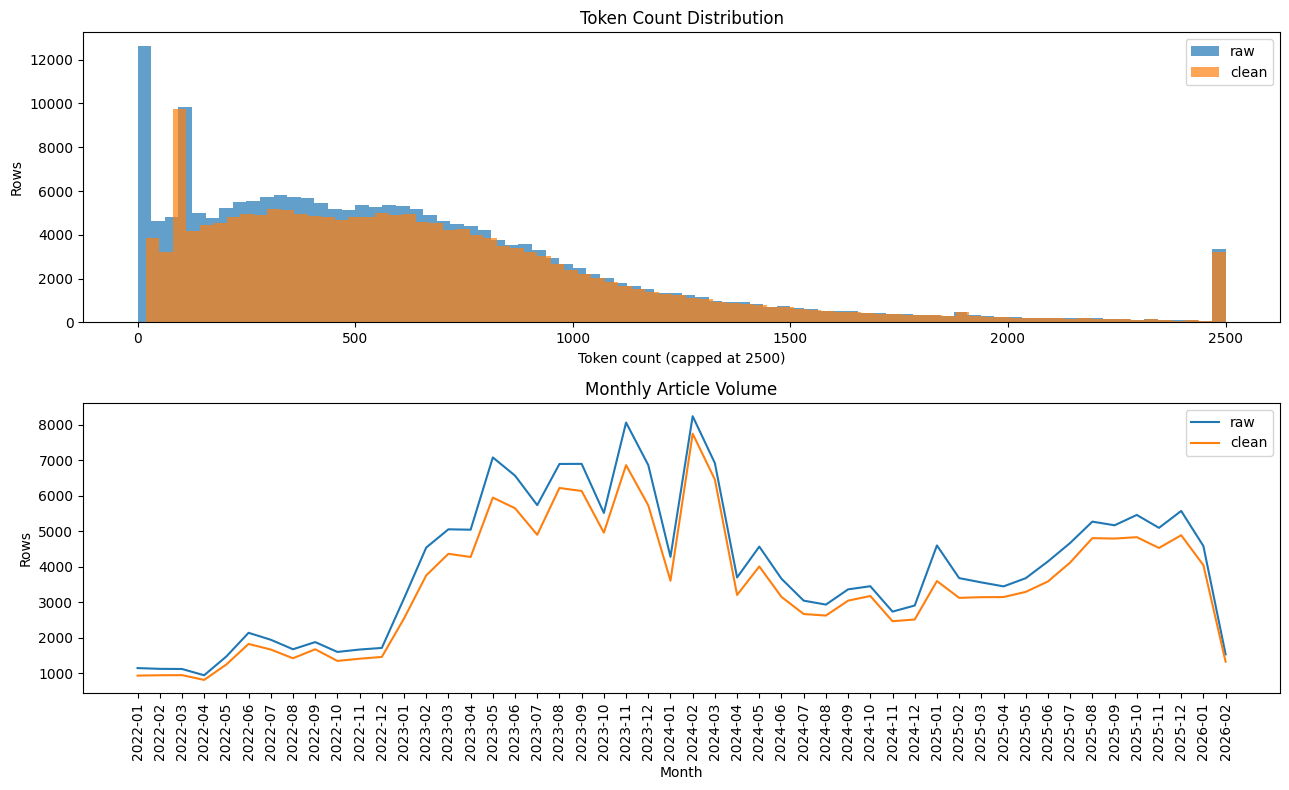

In [22]:
raw_token_counts = work_df["token_count"].clip(upper=2500)
clean_token_counts = clean_df["token_count"].clip(upper=2500)

fig, axes = plt.subplots(2, 1, figsize=(13, 8))
axes[0].hist(raw_token_counts, bins=80, alpha=0.7, label="raw")
axes[0].hist(clean_token_counts, bins=80, alpha=0.7, label="clean")
axes[0].set_title("Token Count Distribution")
axes[0].set_xlabel("Token count (capped at 2500)")
axes[0].set_ylabel("Rows")
axes[0].legend()

raw_month = work_df["date"].dropna().dt.to_period("M").value_counts().sort_index()
clean_month = clean_df["date"].dropna().dt.to_period("M").value_counts().sort_index()
raw_month.index = raw_month.index.astype(str)
clean_month.index = clean_month.index.astype(str)

axes[1].plot(raw_month.index, raw_month.values, label="raw", linewidth=1.5)
axes[1].plot(clean_month.index, clean_month.values, label="clean", linewidth=1.5)
axes[1].set_title("Monthly Article Volume")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Rows")
axes[1].tick_params(axis="x", rotation=90)
axes[1].legend()

plt.tight_layout()
plt.show()

### 6.3 Inspect examples of removed rows

Reviewing a few removed examples is a useful sanity check because it shows whether the filtering rules are mostly excluding noise, off-topic material, or otherwise low-value rows. This makes it easier to judge whether the rule set is too aggressive or reasonably targeted.

In [ ]:
removed_sample = work_df.loc[
    ~work_df["keep_after_relevance"],
    ["title", "text", "url", "language", "token_count", "drop_noise", "is_relevant"],
]

print("Sample of removed rows:\n")
removed_sample.sample(5, random_state=42).apply(
    lambda row: print(
        f"Title: {row['title']}\nText: {row['text']}\nURL: {row['url']}\nLanguage: {row['language']}\nToken Count: {row['token_count']}\nDrop Noise: {row['drop_noise']}\nIs Relevant: {row['is_relevant']}\n{'-'*80}"
        ), axis=1
    )

Sample of removed rows:

Title: Reparations campaigns get boost from new philanthropic funding – FOX21 News Colorado
Text: 
URL: https://www.fox21news.com/business/ap-business/reparations-campaigns-get-boost-from-new-philanthropic-funding/
Language: en
Token Count: 0
Drop Noise: True
Is Relevant: False
--------------------------------------------------------------------------------
Title: SETI Receives $200 Million Philanthropic Gift to Continue Search for Extraterrestrial Life
Text: 
URL: https://citylife.capetown/tr/science/are-we-alone-200-million-gift-from-late-tech-mogul-to-fund-search-for-extraterrestrial-life/450720/
Language: en
Token Count: 0
Drop Noise: True
Is Relevant: False
--------------------------------------------------------------------------------
Title: Latin American schools embrace AI chatbots
Text: 
URL: http://www.source.ly/117jr
Language: en
Token Count: 0
Drop Noise: True
Is Relevant: True
-----------------------------------------------------------------------

67454     None
105275    None
122741    None
77254     None
44192     None
dtype: object

### 6.4 Inspect examples of retained rows

This final qualitative check looks at a few rows that remain in the cleaned dataset. The goal is to verify that the kept documents are readable, AI-related, and suitable for downstream modeling and interpretation.

In [24]:
kept_sample = clean_df.loc[
    :,
    ["title_clean", "text_clean_light", "url", "language", "token_count", "relevance_score"]
]

print("Sample of kept rows:\n")
kept_sample.sample(5, random_state=42).apply(
    lambda row: print(
        f"Clean Title: {row['title_clean']}\nClean Text: {row['text_clean_light']}\nURL: {row['url']}\nLanguage: {row['language']}\nToken Count: {row['token_count']}\nRelevance Score: {row['relevance_score']}\n{'-'*80}"
        ), axis=1
    )

Sample of kept rows:

Clean Title: How AI Can Enhance HR By Transforming Candidate And Employee Experiences
Clean Text: How AI Can Enhance HR By Transforming Candidate And Employee ExperiencesSubscribe To NewslettersBETAThis is a BETA experience. You may opt-out by clicking hereMore From ForbesJun 10, 2024,08:15am EDT20 Economic And Market Trends Shaping The Talent LandscapeJun 10, 2024,07:30am EDTThe Perks Of Partnering With A Business-Savvy Creative AgencyJun 10, 2024,07:15am EDTIs A Fractional CMO Right For Your Company?Jun 10, 2024,07:15am EDTPerseverance Vs. EnduranceJun 10, 2024,07:00am EDTB2B Brand Storytelling And How To Resonate Powerfully With ProspectsJun 10, 2024,07:00am EDTThe Paradox Of Labeling: A Necessary Tool Or A Barrier To Authentic Action And Understanding?Jun 7, 2024,01:15pm EDT20 Ways To Help Your Quiet Employees Speak UpEdit StoryForbesLeadershipHow AI Can Enhance HR By Transforming Candidate And Employee ExperiencesWill GainesForbes Councils MemberForbes Human 

138285    None
9662      None
83814     None
137429    None
186633    None
dtype: object

**Section takeaway:** The exported dataset is supported by both quantitative diagnostics and qualitative spot checks, which gives confidence that the cleaning and filtering pipeline is producing a stronger modeling corpus.

## Final Note

Overall, this notebook transforms the raw crawled news data into a cleaner, more relevant, and more reproducible analytical dataset. By combining evidence extraction, light normalization, transparent rule-based filtering, relevance scoring, and deduplication, the final output is better aligned with the project goal of studying how AI is affecting industries and organizations over time.